Multiple Sequence Alingment


In [ ]:
# ============================================================
# TASK 4: Multiple Sequence Alignment (MSA) using Biopython
# Tools: MUSCLE v5, MAFFT, + Built-in Progressive MSA
# ============================================================


# ───────────────────────────────────────────────
# CELL 1 — Imports
# ───────────────────────────────────────────────

import os
import time
import tracemalloc
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import PairwiseAligner, MultipleSeqAlignment, substitution_matrices

# ── Tool paths ── 
MUSCLE_EXE = r"C:\Users\GADGET STORE\Desktop\bioinformatics-notes\SequenceAllignmentWithBiopython\muscle-win64.v5.3.exe"
MAFFT_EXE  = r"C:\mafft-win\mafft.bat"

print("Libraries loaded!")
print(f"MUSCLE : {MUSCLE_EXE}")
print(f"MAFFT  : {MAFFT_EXE}")


Libraries loaded!
MUSCLE : C:\Users\GADGET STORE\Desktop\bioinformatics-notes\SequenceAllignmentWithBiopython\muscle-win64.v5.3.exe
MAFFT  : C:\mafft-win\mafft.bat


In [3]:


# ───────────────────────────────────────────────
# CELL 2 — Load Sequences
# ───────────────────────────────────────────────

# OPTION A: Load from your own FASTA files
sequences = list(SeqIO.parse("hemoglobin_gallusgallus.fasta", "fasta"))
sequences += list(SeqIO.parse("hemoglobin_homosapien.fasta", "fasta"))
sequences += list(SeqIO.parse("gaga.fasta", "fasta"))



# Save sequences to a temporary FASTA file (needed by MUSCLE and MAFFT)
input_fasta = "msa_input.fasta"
SeqIO.write(sequences, input_fasta, "fasta")

print(f"Loaded {len(sequences)} sequences:\n")
for s in sequences:
    print(f"  {s.id:<12} | length={len(s.seq)} | {s.description}")
print(f"\nSaved to: {input_fasta}")



Loaded 3 sequences:

  NP_990820.1  | length=147 | NP_990820.1 hemoglobin subunit beta [Gallus gallus]
  NP_000509.1  | length=147 | NP_000509.1 hemoglobin subunit beta [Homo sapiens]
  CAN2390221.1 | length=142 | CAN2390221.1 Hemoglobin subunit [Pristimantis euphronides]

Saved to: msa_input.fasta


In [4]:

# ───────────────────────────────────────────────
# CELL 3 — Helper: Alignment Statistics
# ───────────────────────────────────────────────

def alignment_statistics(msa):
    """Compute per-column conservation statistics for an MSA."""
    n_seqs    = len(msa)
    aln_len   = msa.get_alignment_length()
    conserved = gapped = variable = 0
    per_col   = []

    for i in range(aln_len):
        col     = msa[:, i]
        has_gap = "-" in col
        unique  = set(c for c in col if c != "-")

        if has_gap:
            gapped += 1
            per_col.append("gapped")
        elif len(unique) == 1:
            conserved += 1
            per_col.append("conserved")
        else:
            variable += 1
            per_col.append("variable")

    conservation_score = round(conserved / aln_len * 100, 2)
    stats = {
        "Total columns":      aln_len,
        "Conserved columns":  conserved,
        "Variable columns":   variable,
        "Gapped columns":     gapped,
        "Conservation score": f"{conservation_score}%",
    }
    return stats, per_col

print("alignment_statistics() defined.")



alignment_statistics() defined.


In [5]:

# ───────────────────────────────────────────────
# CELL 4 — Method 1: Built-in Progressive MSA
# ───────────────────────────────────────────────

def progressive_msa(sequences, matrix_name="BLOSUM62", gap_open=-10, gap_extend=-0.5):
    """
    Progressive MSA using Biopython's PairwiseAligner.
    Aligns each sequence progressively to the anchor (first) sequence.
    Strategy similar to ClustalW.
    """
    aligner                     = PairwiseAligner()
    aligner.mode                = "global"
    aligner.substitution_matrix = substitution_matrices.load(matrix_name)
    aligner.open_gap_score      = gap_open
    aligner.extend_gap_score    = gap_extend

    anchor     = str(sequences[0].seq)
    aligned    = [None] * len(sequences)
    aligned[0] = anchor

    for i in range(1, len(sequences)):
        target     = str(sequences[i].seq)
        best       = next(iter(aligner.align(anchor, target)))
        aligned[0] = str(best[0])
        aligned[i] = str(best[1])

    max_len = max(len(s) for s in aligned if s is not None)
    aligned = [s.ljust(max_len, "-") if s else "-" * max_len for s in aligned]
    return aligned


# Run and measure
print("Running Progressive MSA (Biopython built-in)...")
tracemalloc.start()
start        = time.time()
prog_aligned = progressive_msa(sequences)
prog_time    = round(time.time() - start, 4)
_, prog_mem  = tracemalloc.get_traced_memory()
tracemalloc.stop()
prog_mem_kb  = round(prog_mem / 1024, 2)

# Build MSA object
prog_msa = MultipleSeqAlignment([
    SeqRecord(Seq(aln), id=rec.id, description=rec.description)
    for rec, aln in zip(sequences, prog_aligned)
])

prog_stats, _ = alignment_statistics(prog_msa)

print(f"Done in {prog_time}s | Memory: {prog_mem_kb} KB")
print(f"Alignment length : {prog_msa.get_alignment_length()} columns")
print(f"Conservation     : {prog_stats['Conservation score']}")
print(f"\nAlignment preview (first 80 cols):")
for rec in prog_msa:
    print(f"  {rec.id:<12}: {str(rec.seq)[:80]}")



Running Progressive MSA (Biopython built-in)...
Done in 0.0452s | Memory: 74.44 KB
Alignment length : 149 columns
Conservation     : 4.03%

Alignment preview (first 80 cols):
  NP_990820.1 : MVHWTAEEKQLITGLWGKV--NVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAILGNPMVRAHGKKVLTSFGDAVKN
  NP_000509.1 : MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLD
  CAN2390221.1: MT-FSDAEKAAIVSILGKASKDVSGLGGEALERLFLGFPQTKTYFSHF-DLSH-----GSSDVRAHGGKVLGAIVEAAKH


In [6]:

# ───────────────────────────────────────────────
# CELL 5 — Method 2: MUSCLE v5 Alignment
# ───────────────────────────────────────────────

def run_muscle(input_fasta, output_fasta, muscle_exe=MUSCLE_EXE):
    """
    Run MUSCLE v5 alignment via subprocess.
    MUSCLE v5 uses: muscle -align input.fasta -output output.fasta
    """
    cmd = [muscle_exe, "-align", input_fasta, "-output", output_fasta]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("MUSCLE error:", result.stderr)
        return None
    return AlignIO.read(output_fasta, "fasta")


# Run and measure
print("Running MUSCLE v5 alignment...")
muscle_output = "msa_muscle.fasta"

tracemalloc.start()
start          = time.time()
muscle_msa     = run_muscle(input_fasta, muscle_output)
muscle_time    = round(time.time() - start, 4)
_, muscle_mem  = tracemalloc.get_traced_memory()
tracemalloc.stop()
muscle_mem_kb  = round(muscle_mem / 1024, 2)

if muscle_msa:
    muscle_stats, _ = alignment_statistics(muscle_msa)
    print(f"Done in {muscle_time}s | Memory: {muscle_mem_kb} KB")
    print(f"Alignment length : {muscle_msa.get_alignment_length()} columns")
    print(f"Conservation     : {muscle_stats['Conservation score']}")
    print(f"\nAlignment preview (first 80 cols):")
    for rec in muscle_msa:
        print(f"  {rec.id:<12}: {str(rec.seq)[:80]}")



Running MUSCLE v5 alignment...
Done in 0.3037s | Memory: 45.1 KB
Alignment length : 149 columns
Conservation     : 35.57%

Alignment preview (first 80 cols):
  CAN2390221.1: MTF-SDAEKAAIVSILGKASKDVSGLGGEALERLFLGFPQTKTYFSHF-DLS-----HGSSDVRAHGGKVLGAIVEAAKH
  NP_990820.1 : MVHWTAEEKQLITGLWGKV--NVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAILGNPMVRAHGKKVLTSFGDAVKN
  NP_000509.1 : MVHLTPEEKSAVTALWGKV--NVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAH


In [7]:

# ───────────────────────────────────────────────
# CELL 6 — Method 3: MAFFT Alignment
# ───────────────────────────────────────────────

def run_mafft(input_fasta, output_fasta, mafft_exe=MAFFT_EXE):
    """
    Run MAFFT alignment via subprocess.
    MAFFT uses: mafft --auto input.fasta > output.fasta
    """
    cmd    = [mafft_exe, "--auto", "--quiet", input_fasta]
    result = subprocess.run(cmd, capture_output=False,
                            stdout=open(output_fasta, "w"), text=True)
    if result.returncode != 0:
        print("MAFFT error:", result.stderr)
        return None
    return AlignIO.read(output_fasta, "fasta")


# Run and measure
print("Running MAFFT alignment...")
mafft_output = "msa_mafft.fasta"

tracemalloc.start()
start         = time.time()
mafft_msa     = run_mafft(input_fasta, mafft_output)
mafft_time    = round(time.time() - start, 4)
_, mafft_mem  = tracemalloc.get_traced_memory()
tracemalloc.stop()
mafft_mem_kb  = round(mafft_mem / 1024, 2)

if mafft_msa:
    mafft_stats, _ = alignment_statistics(mafft_msa)
    print(f"Done in {mafft_time}s | Memory: {mafft_mem_kb} KB")
    print(f"Alignment length : {mafft_msa.get_alignment_length()} columns")
    print(f"Conservation     : {mafft_stats['Conservation score']}")
    print(f"\nAlignment preview (first 80 cols):")
    for rec in mafft_msa:
        print(f"  {rec.id:<12}: {str(rec.seq)[:80]}")



Running MAFFT alignment...
Done in 14.5133s | Memory: 25.77 KB
Alignment length : 149 columns
Conservation     : 35.57%

Alignment preview (first 80 cols):
  NP_990820.1 : MVHWTAEEKQLITGLWGKV--NVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAILGNPMVRAHGKKVLTSFGDAVKN
  NP_000509.1 : MVHLTPEEKSAVTALWGKV--NVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAH
  CAN2390221.1: M-TFSDAEKAAIVSILGKASKDVSGLGGEALERLFLGFPQTKTYFSHF-DLSH-----GSSDVRAHGGKVLGAIVEAAKH


In [8]:

# ───────────────────────────────────────────────
# CELL 7 — Compare All Three Methods
# ───────────────────────────────────────────────

comparison_data = []

# Progressive MSA
comparison_data.append({
    "Method":           "Progressive (Biopython)",
    "Time (s)":         prog_time,
    "Memory (KB)":      prog_mem_kb,
    "Aln Length":       prog_msa.get_alignment_length(),
    "Conserved Cols":   prog_stats["Conserved columns"],
    "Gapped Cols":      prog_stats["Gapped columns"],
    "Conservation %":   prog_stats["Conservation score"],
})

# MUSCLE
if muscle_msa:
    comparison_data.append({
        "Method":           "MUSCLE v5",
        "Time (s)":         muscle_time,
        "Memory (KB)":      muscle_mem_kb,
        "Aln Length":       muscle_msa.get_alignment_length(),
        "Conserved Cols":   muscle_stats["Conserved columns"],
        "Gapped Cols":      muscle_stats["Gapped columns"],
        "Conservation %":   muscle_stats["Conservation score"],
    })

# MAFFT
if mafft_msa:
    comparison_data.append({
        "Method":           "MAFFT",
        "Time (s)":         mafft_time,
        "Memory (KB)":      mafft_mem_kb,
        "Aln Length":       mafft_msa.get_alignment_length(),
        "Conserved Cols":   mafft_stats["Conserved columns"],
        "Gapped Cols":      mafft_stats["Gapped columns"],
        "Conservation %":   mafft_stats["Conservation score"],
    })

comp_df = pd.DataFrame(comparison_data)
print("── Method Comparison ──")
print(comp_df.to_string(index=False))


── Method Comparison ──
                 Method  Time (s)  Memory (KB)  Aln Length  Conserved Cols  Gapped Cols Conservation %
Progressive (Biopython)    0.0452        74.44         149               6           11          4.03%
              MUSCLE v5    0.3037        45.10         149              53            9         35.57%
                  MAFFT   14.5133        25.77         149              53            9         35.57%


C:\Users\GADGET STORE\AppData\Local\Temp\ipykernel_7176\3539430429.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(methods, rotation=15, ha="right")
C:\Users\GADGET STORE\AppData\Local\Temp\ipykernel_7176\3539430429.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, rotation=15, ha="right")
C:\Users\GADGET STORE\AppData\Local\Temp\ipykernel_7176\3539430429.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(methods, rotation=15, ha="right")


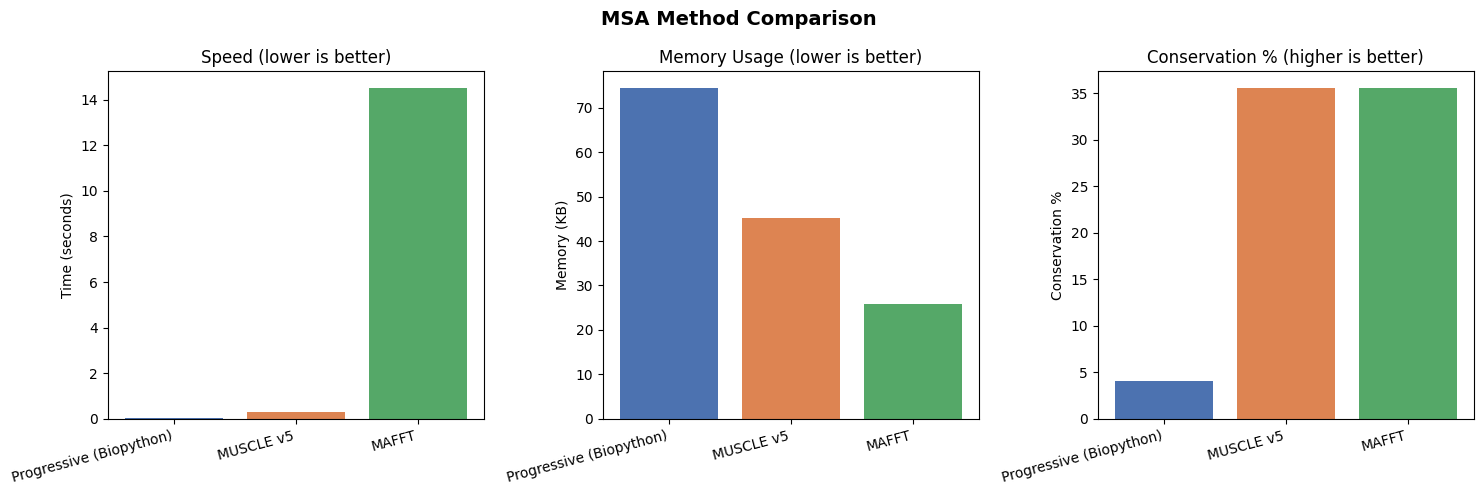

Saved as method_comparison.png


In [9]:


# ───────────────────────────────────────────────
# CELL 8 — Visualize Comparison as Bar Charts
# ───────────────────────────────────────────────

methods = comp_df["Method"].tolist()
colors  = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("MSA Method Comparison", fontsize=14, fontweight="bold")

# Speed
axes[0].bar(methods, comp_df["Time (s)"], color=colors)
axes[0].set_title("Speed (lower is better)")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_xticklabels(methods, rotation=15, ha="right")

# Memory
axes[1].bar(methods, comp_df["Memory (KB)"], color=colors)
axes[1].set_title("Memory Usage (lower is better)")
axes[1].set_ylabel("Memory (KB)")
axes[1].set_xticklabels(methods, rotation=15, ha="right")

# Conservation
conservation_vals = [float(v.strip("%")) for v in comp_df["Conservation %"]]
axes[2].bar(methods, conservation_vals, color=colors)
axes[2].set_title("Conservation % (higher is better)")
axes[2].set_ylabel("Conservation %")
axes[2].set_xticklabels(methods, rotation=15, ha="right")

plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as method_comparison.png")


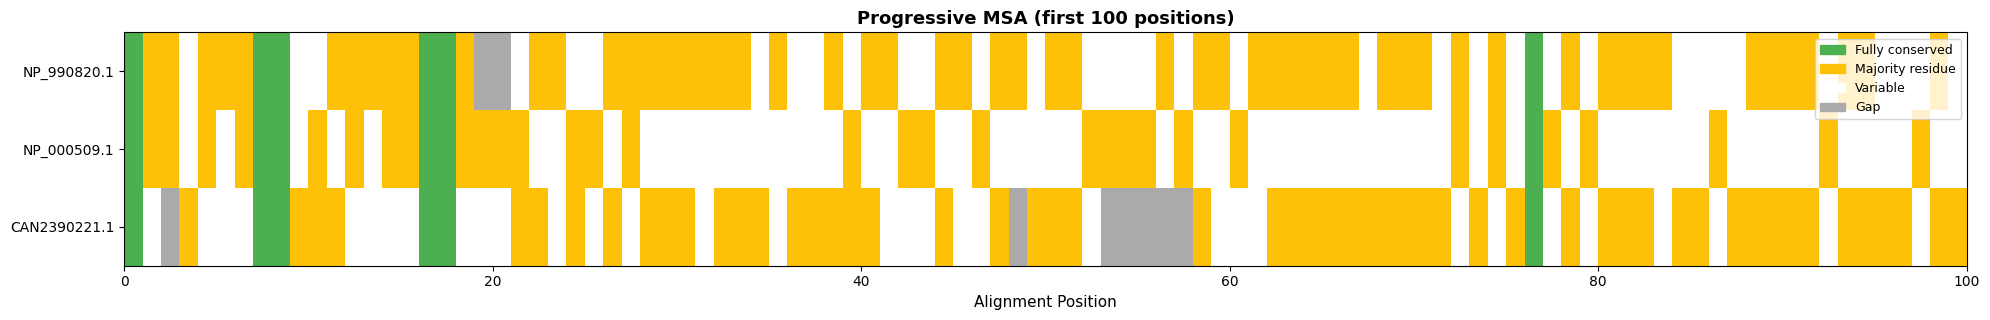

Saved as Progressive_MSA.png


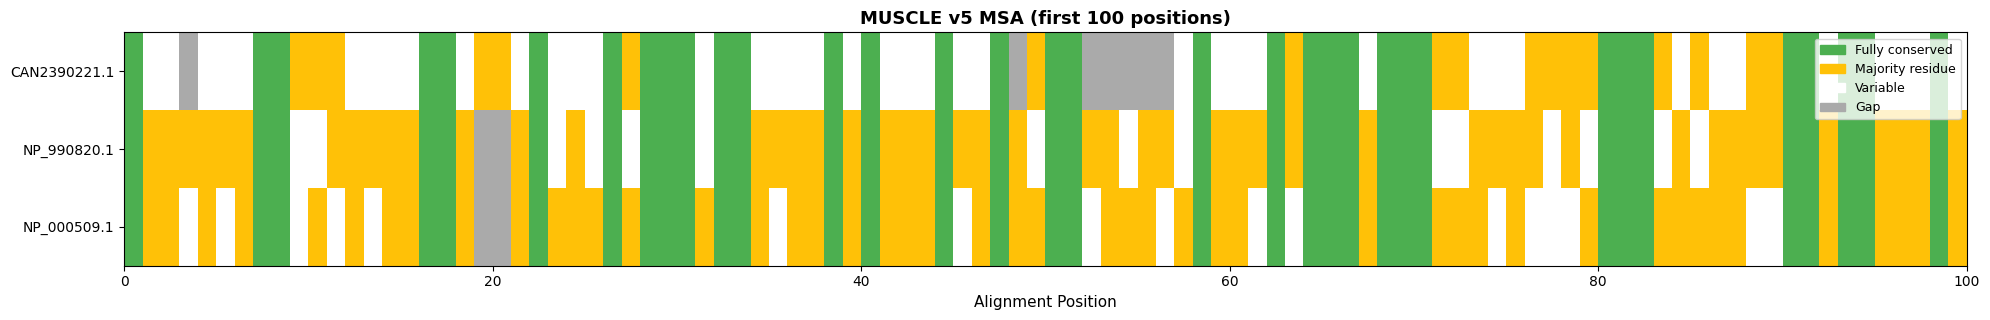

Saved as MUSCLE_v5_MSA.png


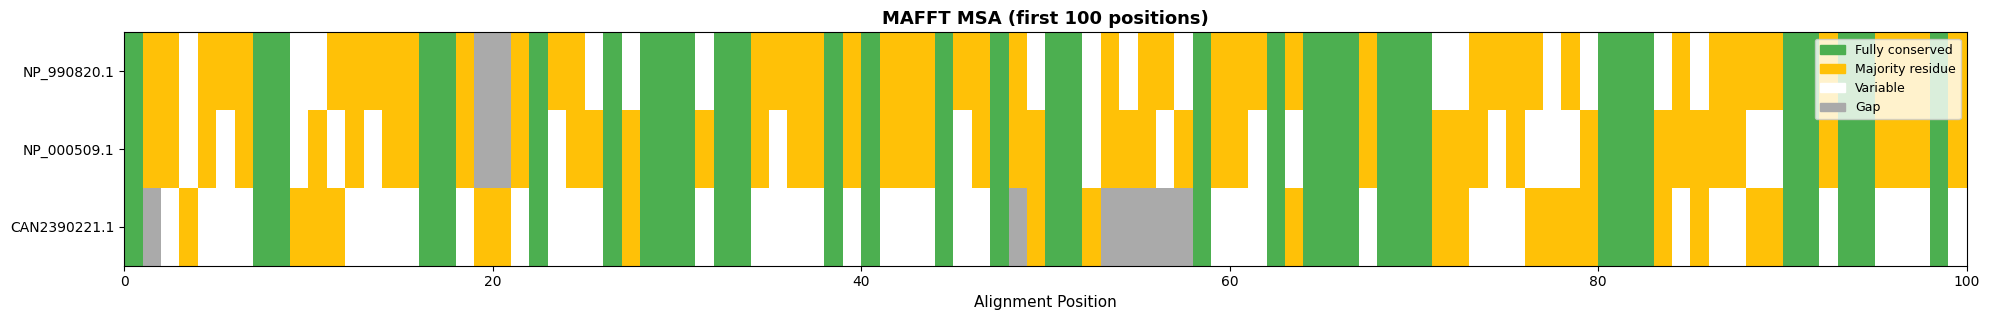

Saved as MAFFT_MSA.png


In [11]:


# ───────────────────────────────────────────────
# CELL 9 — Visualize MSA Alignment (color grid)
# ───────────────────────────────────────────────

def visualize_msa(msa, title="MSA Visualization", max_cols=100):
    """Color-coded MSA grid: Green=conserved, Yellow=majority, White=variable, Gray=gap."""
    n_seqs  = len(msa)
    aln_len = min(msa.get_alignment_length(), max_cols)
    ids     = [r.id for r in msa]

    color_matrix = []
    for col_i in range(aln_len):
        col      = msa[:, col_i]
        residues = [c for c in col if c != "-"]
        row_colors = []
        for char in col:
            if char == "-":
                row_colors.append("#AAAAAA")
            elif len(set(residues)) == 1 and len(residues) == n_seqs:
                row_colors.append("#4CAF50")
            elif residues and char == max(set(residues), key=residues.count):
                row_colors.append("#FFC107")
            else:
                row_colors.append("#FFFFFF")
        color_matrix.append(row_colors)

    fig, ax = plt.subplots(figsize=(20, n_seqs * 0.6 + 1.5))
    ax.set_xlim(0, aln_len)
    ax.set_ylim(0, n_seqs)
    ax.set_facecolor("#F5F5F5")

    for col_i in range(aln_len):
        for seq_i in range(n_seqs):
            rect = mpatches.Rectangle(
                (col_i, n_seqs - seq_i - 1), 1, 1,
                linewidth=0, facecolor=color_matrix[col_i][seq_i]
            )
            ax.add_patch(rect)

    ax.set_yticks([n_seqs - i - 0.5 for i in range(n_seqs)])
    ax.set_yticklabels(ids, fontsize=10)
    ax.set_xlabel("Alignment Position", fontsize=11)
    ax.set_title(f"{title} (first {aln_len} positions)", fontsize=13, fontweight="bold")
    legend = [
        mpatches.Patch(color="#4CAF50", label="Fully conserved"),
        mpatches.Patch(color="#FFC107", label="Majority residue"),
        mpatches.Patch(color="#FFFFFF", label="Variable"),
        mpatches.Patch(color="#AAAAAA", label="Gap"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved as {title.replace(' ', '_')}.png")


# Visualize all three
visualize_msa(prog_msa,   title="Progressive MSA")
visualize_msa(muscle_msa, title="MUSCLE v5 MSA")
visualize_msa(mafft_msa,  title="MAFFT MSA")


In [12]:


# ───────────────────────────────────────────────
# CELL 10 — Consensus Sequence from each method
# ───────────────────────────────────────────────

def generate_consensus(msa, threshold=0.7):
    """Generate consensus sequence — most frequent residue at each column."""
    consensus = []
    n_seqs    = len(msa)

    for i in range(msa.get_alignment_length()):
        col     = msa[:, i]
        counts  = {}
        for char in col:
            counts[char] = counts.get(char, 0) + 1
        most_common = max(counts, key=counts.get)
        freq        = counts[most_common] / n_seqs
        consensus.append(most_common if freq >= threshold else "X")

    return "".join(consensus)


print("── Consensus Sequences (70% threshold) ──\n")

prog_consensus   = generate_consensus(prog_msa)
print(f"Progressive : {prog_consensus[:80]}")

if muscle_msa:
    muscle_consensus = generate_consensus(muscle_msa)
    print(f"MUSCLE      : {muscle_consensus[:80]}")

if mafft_msa:
    mafft_consensus  = generate_consensus(mafft_msa)
    print(f"MAFFT       : {mafft_consensus[:80]}")



── Consensus Sequences (70% threshold) ──

Progressive : MXXXXXXEKXXXXXXXGKXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXAXXX
MUSCLE      : MXXXXXXEKXXXXXXXGKXXXXVXXXGXEALXRLXXXXPXTXXXFXXFXXLSXXXXXXGXXXVXAHGXKVLXXXXXXXXX
MAFFT       : MXXXXXXEKXXXXXXXGKXXXXVXXXGXEALXRLXXXXPXTXXXFXXFXXLSXXXXXXGXXXVXAHGXKVLXXXXXXXXX


In [ ]:

# ───────────────────────────────────────────────
# CELL 11 — Save All Alignments to File
# ───────────────────────────────────────────────

AlignIO.write(prog_msa, "progressive_result.clustal", "clustal")
print("Saved: progressive_result.clustal")

if muscle_msa:
    AlignIO.write(muscle_msa, "muscle_result.clustal", "clustal")
    print("Saved: muscle_result.clustal")

if mafft_msa:
    AlignIO.write(mafft_msa, "mafft_result.clustal", "clustal")
    print("Saved: mafft_result.clustal")

print("\nAll alignments saved! Task 4 complete.")